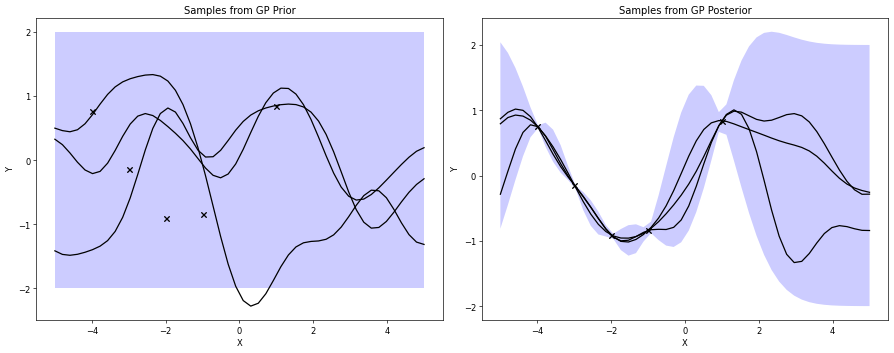

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

np.random.seed(42)

class GaussianProcessRegressor:

    def __init__(self, X_train, y_train, X_test):

        self.L = 1.0
        self.keps = 1e-8

        self.muFn = self.mean_func(X_test)
        self.Kfn = self.kernel_func(X_test, X_test) + 1e-15*np.eye(np.size(X_test))

        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test

    def mean_func(self, x):
        muFn = np.zeros(len(x)).reshape(-1,1)
        return muFn

    def kernel_func(self, x, z):
        sq_dist = cdist(x/self.L, z/self.L, 'euclidean')**2
        Kfn = 1.0 * np.exp(-sq_dist/2)
        return Kfn

    def compute_posterior(self):
        K = self.kernel_func(self.X_train, self.X_train)  #K
        Ks = self.kernel_func(self.X_train, self.X_test)  #K_*
        Kss = self.kernel_func(self.X_test, self.X_test) + self.keps*np.eye(np.size(self.X_test))  #K_**
        Ki = np.linalg.inv(K) #O(Ntrain^3)

        postMu = self.mean_func(self.X_test) + np.dot(np.transpose(Ks), np.dot(Ki, (self.y_train - self.mean_func(self.X_train))))
        postCov = Kss - np.dot(np.transpose(Ks), np.dot(Ki, Ks))

        self.muFn = postMu
        self.Kfn = postCov

        return None

    def generate_plots(self, X, ax, num_samples=3, title=""): # Added ax and title arguments
        ax.cla() # Clear previous plot if any
        for i in range(num_samples):
            fs = self.gauss_sample(1)
            ax.plot(X, fs, '-k')
            ax.plot(self.X_train, self.y_train, 'xk')

        mu = self.muFn.ravel()
        S2 = np.diag(self.Kfn)
        ax.fill(np.concatenate([X.ravel(), X.ravel()[::-1]]),
                np.concatenate([mu - 2*np.sqrt(S2), (mu + 2*np.sqrt(S2))[::-1]]),
                alpha=0.2, fc='b')
        ax.set_title(title)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')

    def gauss_sample(self, n):
        # returns n samples from a multivariate Gaussian distribution
        # S = AZ + mu
        A = np.linalg.cholesky(self.Kfn)
        Z = np.random.normal(loc=0, scale=1, size=(len(self.muFn),n))
        S = np.dot(A,Z) + self.muFn
        return S

def main():

    # generate noise-less training data
    X_train = np.array([-4, -3, -2, -1, 1])
    X_train = X_train.reshape(-1,1)
    y_train = np.sin(X_train)

    # generate  test data
    X_test = np.linspace(-5, 5, 50)
    X_test = X_test.reshape(-1,1)

    gp = GaussianProcessRegressor(X_train, y_train, X_test)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=60)

    gp.generate_plots(X_test, ax1, 3, "Samples from GP Prior")  # samples from GP prior
    gp.compute_posterior()
    gp.generate_plots(X_test, ax2, 3, "Samples from GP Posterior")  # samples from GP posterior

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()